# Lab 061 · Learn Bayesian prediction across tasks

[Lesson](../lessons/0061-prior-data-fitted-networks.html) · [Reference](../reference/0061-prior-data-fitted-networks.html) · [Reproduction contract](l061-reproduction.md)

**Route:** retrieve → explain → predict → implement → CHECK → inspect evidence → EXIT. PROVIDED cells are readable implementation and peripheral support. TODOs contain your load-bearing code; CHECKs give immediate diagnostic feedback. Complete the code before revealing teacher solutions. Core study: 35–50 minutes; lab: 45–75 minutes plus explicitly gated larger runs.

**Before reading:** Must a learned posterior approximation extrapolate beyond its training context sizes? Write your answer and justify the information boundary. Then recall one older lesson that could expose an error in this experiment.

**Evidence contract:** numerical figures labeled author-reference come from committed author measurements. They are not outputs of your current kernel. Reduced model mechanisms, pretrained reference inference, frozen-result reanalysis and paper reproduction are different tracks. Every track states its scope below.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Learn an inference procedure

A conventional classifier learns one mapping from features to labels on one training dataset. A **prior-data fitted network (PFN)** learns across many sampled supervised-learning tasks. Its input includes a new task's labeled context and an unlabeled query. Its output approximates the label distribution implied by the prior and that context. Read [Müller et al., Sections 2–3](https://arxiv.org/html/2112.10510v7).

Separate three objects: the prior over tasks, the distribution of examples within a task, and the neural weights shared across tasks. During pretraining, gradients update those weights. At ordinary in-context inference, the weights are fixed; context examples alter the computation and therefore the answer. Calling the latter “no training” is shorthand for no downstream parameter optimization, not zero learning cost or no use of labels.

## Derive a posterior you can check exactly

Let a task be an unknown coin probability theta. Draw theta from a Beta distribution with positive shape parameters alpha and beta. Conditional on theta, each observed label is a Bernoulli draw: 1 with probability theta, otherwise 0. For a context with s successes and f failures, multiplying the prior density by its likelihood gives exponents `alpha+s−1` and `beta+f−1`. The posterior is therefore `Beta(alpha+s, beta+f)`.

To predict the next label, integrate over this posterior instead of plugging in one fitted theta. The next-success probability is `(alpha+s)/(alpha+beta+s+f)`. For a uniform `Beta(1,1)` prior and labels `[1,0,1]`, the prediction is `3/5=.6`. The empirical success rate is `2/3`; the Bayesian answer shrinks it toward the prior mean `.5`. With no observations, it returns the prior mean. More observations reduce the prior's relative contribution.

The output `.5` alone does not distinguish a well-known fair coin from uncertainty between nearly deterministic coins. A posterior predictive probability mixes uncertainty about the task with randomness within it. If you need a posterior distribution over theta, that is a different output contract.

<div style="overflow-x:auto;max-width:100%">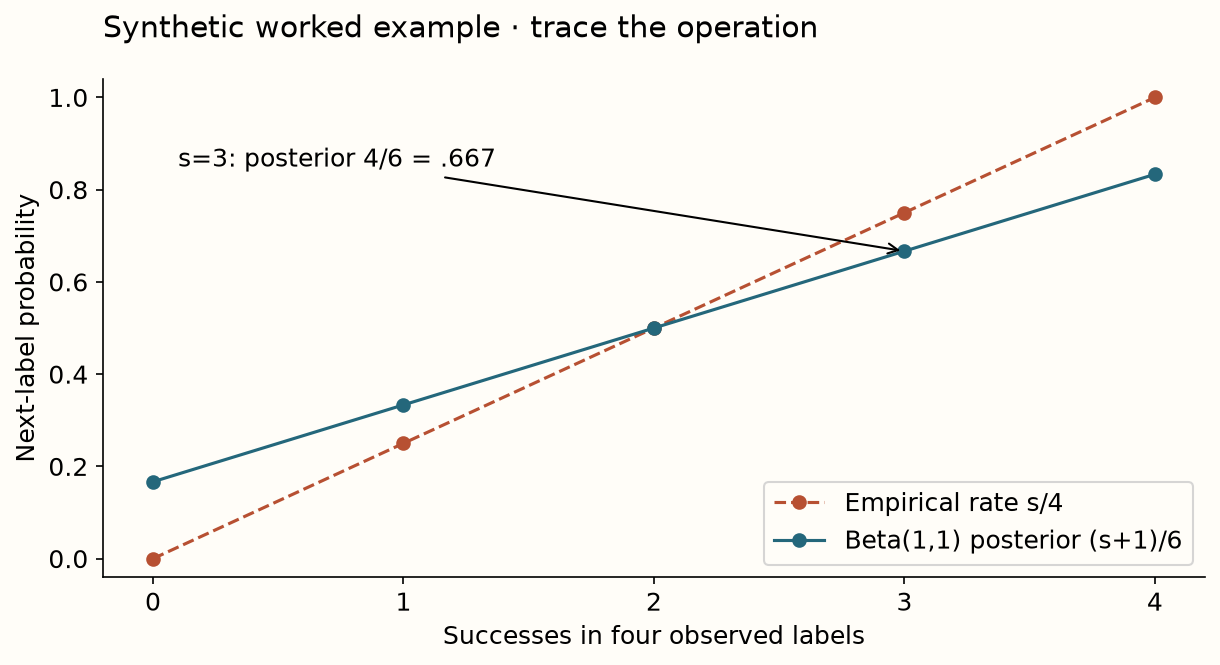</div>

*L061 mechanism: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

## Why query-label loss learns the Bayesian answer

Sample a task, draw context labels and draw an independent query label from the same task. Train a network to predict the query from the context using binary cross-entropy, `−y log(q)−(1−y)log(1−q)`. Conditional on a particular context, let p be the true posterior predictive probability. Expected query loss is `−p log(q)−(1−p)log(1−q)`.

Differentiating with respect to q gives `−p/q+(1−p)/(1−q)`, which vanishes at `q=p`. Equivalently, expected log loss is the true predictive entropy plus a nonnegative KL divergence between the true prediction and the model's prediction. Finite capacity, optimization and the sampled training distribution determine how closely a neural network reaches that optimum. The theorem does not say an arbitrary trained Transformer has become an exact Bayesian engine for every real table.

The context and query must share the same sampled theta. If you redraw theta for the query, context labels contain no information about it; the best predictor collapses to the prior mean. The lab asks you to construct this broken generator as a negative control.

## Model architecture: isolate the PFN objective

The local **CountPFN** uses the exact sufficient statistics `[successes, failures]`, divides them by 32, and passes them through `2→32→32→1` affine layers with GELU nonlinearities. A sigmoid turns the final logit into a next-success probability. A sufficient statistic retains all information about theta that these exchangeable Bernoulli observations provide. Using it removes representation learning from this first experiment.

This is a complete PFN-objective demonstration, not a Transformer or TabPFN implementation. The paper's general architecture embeds examples and learns set-conditioned prediction using attention. Lesson 62 introduces that row-token route; the count encoder here is an intentional decomposition so you can independently verify the learning objective before adding attention and richer priors.

<div style="overflow-x:auto;max-width:100%">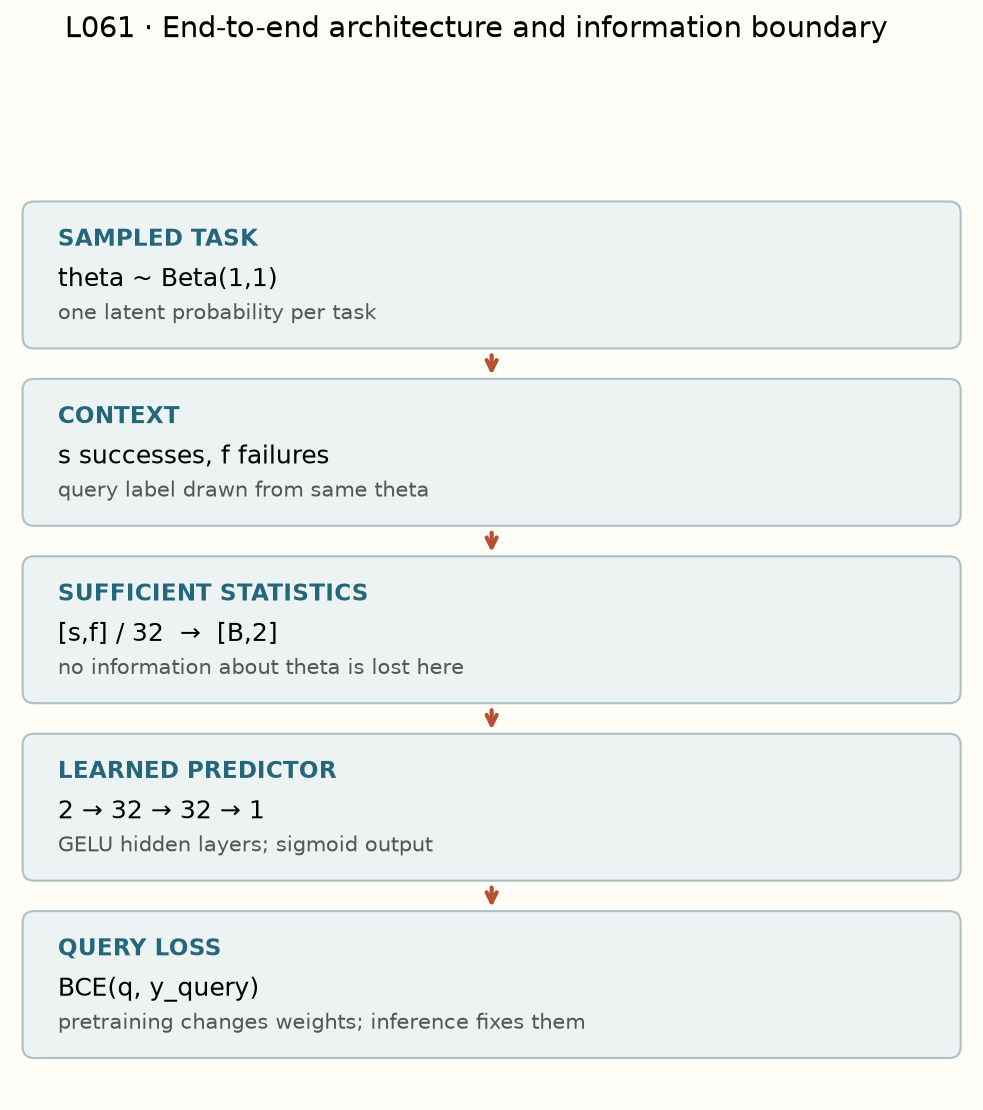</div>

*L061 architecture: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

## Fit on sampled tasks, evaluate against analysis

Each of three author runs takes 1,500 optimizer steps, with 256 independently sampled coin tasks per step and context lengths from 1 through 32. Training targets are sampled query labels, not analytic posterior values. The evaluation grid checks every success count at context lengths 4, 16 and 32, then challenges extrapolation at length 64. The analytic formula appears only in the evaluation path.

Predict whether a small average approximation error inside the training range guarantees accurate length-64 predictions. It does not: the network has learned a function over a sampled range of counts, while the analytic rule holds at every valid length. Plot predicted versus exact probabilities and inspect errors near extreme counts; an overall mean can hide those failures.

<div style="overflow-x:auto;max-width:100%">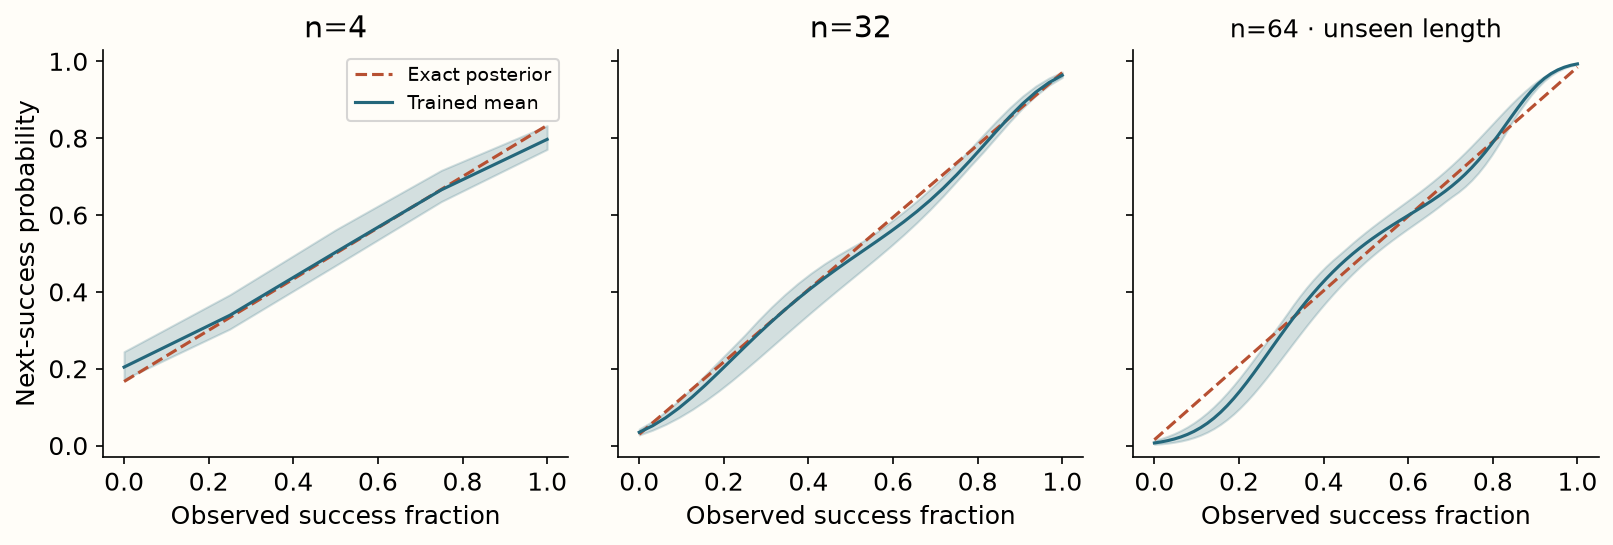</div>

*L061 results: author-reference measurements, separate from your kernel. Scroll wide figures horizontally on small screens.*

## Exit: distinguish three kinds of success

Implement the posterior formula and the task generator, train your predictor and report in-range and extrapolation errors. Compare a constant `.5`, the empirical success rate and the learned predictor against the analytic posterior. Explain why the analytic oracle is an evaluation target, not a fair competitor whose “training time” should be compared with neural pretraining.

Your verdict must separate the correctness of the conjugate calculation, the measured approximation quality of this trained CountPFN, and the broader paper claim about attention-based posterior approximation. Then name what changes for a tabular classification task: the latent task is now a function or generating process, and the labeled context contains features as well as targets.

## Reproduction contract and task support

The visible code below implements the named operator or reduced architecture. The full pretrained model is a separately pinned reference path. Real public-table experiments use Tier A data; synthetic coin/SCM/shift tasks are Tier C mechanism isolation. Seeds, row identities, recipe budgets, versions and source/checkpoint hashes are available in the linked contract and evidence. Numerical agreement with a local operator is not a paper-table reproduction.

In [ ]:
# PROVIDED — environment, peripheral data/metric utilities
import os, sys, math, copy, re, json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.stats import rankdata, friedmanchisquare, studentized_range, t
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold
from threadpoolctl import threadpool_limits
from IPython.display import display
for directory in [Path.cwd(), Path.cwd()/'labs', Path.cwd().parent]:
    if (directory/'relkit').is_dir():
        ROOT=directory.resolve(); sys.path.insert(0,str(ROOT)); break
else:
    raise RuntimeError('Run the Colab bootstrap or start in the course repository')
torch.set_num_threads(1)
from relkit.foundation_benchmark import random_task, encode_train
print('CPU mechanism track; official checkpoint reruns use an isolated subprocess after EXIT.')

In [ ]:
# PROVIDED — CountPFN; inspect the live function calls
class CountPFN(nn.Module):
    """PFN objective with an exact sufficient-statistic encoder, not TabPFN.

    Input [successes, failures]/32; output next-label logit. This deliberately
    removes representation learning so L061 can test posterior approximation.
    """
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(2,32),nn.GELU(),nn.Linear(32,32),nn.GELU(),nn.Linear(32,1))

    def forward(self,counts):
        return self.net(counts/32.).squeeze(-1)

In [ ]:
# PROVIDED — train_count_pfn; inspect the live function calls
def train_count_pfn(seed=0,steps=1500):
    torch.set_num_threads(1);torch.manual_seed(seed);rng=np.random.default_rng(seed+61)
    model=CountPFN();opt=torch.optim.Adam(model.parameters(),lr=.003);history=[]
    for step in range(steps):
        # One probability per task; context AND query share it.
        sampled,query=sample_coin_tasks(rng)
        counts=torch.tensor(sampled,dtype=torch.float32)
        target=torch.tensor(query,dtype=torch.float32)
        loss=nn.functional.binary_cross_entropy_with_logits(model(counts),target)
        opt.zero_grad();loss.backward();opt.step()
        if step%100==0:history.append(dict(step=step,query_loss=float(loss.detach())))
    model.eval();grid=[]
    with torch.no_grad():
        for n in [4,16,32,64]:
            counts=torch.tensor([[s,n-s] for s in range(n+1)],dtype=torch.float32)
            p=model(counts).sigmoid().numpy()
            for s,value in enumerate(p):grid.append(dict(n=n,successes=s,prediction=float(value),exact=posterior_predictive([1]*s+[0]*(n-s)),mle=s/n))
    return model,dict(seed=seed,steps=steps,history=history,grid=grid,
        in_support_mae=float(np.mean([abs(r['prediction']-r['exact']) for r in grid if r['n']<=32])),
        extrapolation_mae=float(np.mean([abs(r['prediction']-r['exact']) for r in grid if r['n']==64])))

## TODO 1 · posterior_predictive

**Goal:** Compute the Beta–Bernoulli next-label probability, including empty context and invalid-prior handling.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 1 — posterior_predictive
def posterior_predictive(labels, alpha=1., beta=1.):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 1 — posterior_predictive
assert posterior_predictive([1,0,1])==.6
assert posterior_predictive([],2,3)==.4
assert posterior_predictive([1,0,1],2,3)==.5
try: posterior_predictive([2])
except ValueError: pass
else: raise AssertionError('Nonbinary labels accepted')

print("PASS: posterior_predictive")

## TODO 2 · sample_coin_tasks

**Goal:** Sample one theta per task; use it for context counts and the query label. Return [successes,failures] float32 counts and query labels.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 2 — sample_coin_tasks
def sample_coin_tasks(rng, batch=256, max_context=32):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 2 — sample_coin_tasks
counts,query=sample_coin_tasks(np.random.default_rng(610),batch=10000,max_context=32)
assert counts.shape==(10000,2) and query.shape==(10000,)
assert (counts>=0).all() and ((counts.sum(1)>=1)&(counts.sum(1)<=32)).all()
cov=np.cov(counts[:,0]/counts.sum(1),query)[0,1]
assert cov>.04, 'Context and query must share theta; a fresh independent query task destroys their dependence'

print("PASS: sample_coin_tasks")

## Run your live implementation

Predict the outcome before execution. This cell calls the functions you just wrote. Changing a TODO must change the corresponding computation or make a CHECK fail. The text printed with the result identifies whether this is a small training run, a mechanism test or a reanalysis of committed measurements.

In [ ]:
# PROVIDED — experiment driven by your live functions
model,trial=train_count_pfn(seed=0,steps=1500)
print({k:trial[k] for k in ['seed','steps','in_support_mae','extrapolation_mae']})
assert trial['in_support_mae']<.12, 'Inspect the task generator and training, not the tolerance, if the posterior fit fails'

## Audit author-reference evidence

Inspect the measured results below independently of your smoke experiment. A fresh smoke may use a smaller budget. Preserve the protocol difference rather than forcing numerical agreement with a different run. The committed prediction arrays let you reconstruct scores without downloading pretrained weights.

In [ ]:
# PROVIDED — readable evidence, never impersonating current-kernel training
author=json.loads((ROOT/'_verify_l061_results.json').read_text())
print('AUTHOR REFERENCE:',author.get('scope',author.get('note','Declared checkpoint experiment')))
print('Evidence verdict:',author.get('verdict'))
rows=author.get('records',author.get('summary',[]))
if isinstance(rows,list) and rows:
    display(pd.DataFrame(rows).drop(columns=['predictions','targets','history','context_ids','task_losses'],errors='ignore').head(24))
if 61 in [60,70]:
    for regime,summary in author['summary'].items():
        print(regime,summary['mean_ranks'],'Friedman p=',summary['friedman_p'],'CD=',summary['nemenyi_cd'])

## EXIT TICKET · submit an executable argument

Provide your code output plus a 30–100 word verdict: which implementation ran, what information it could use, what evidence supports the result, and which paper claim remains untested. Include an unexpected or failed case and a next discriminating experiment. The length check below only enforces an attempt; the tutor grades your reasoning. Do not infer personal mastery from a green code cell.

In [ ]:
# TODO — written verdict; paste the resulting artifact and explanation to the tutor
verdict=''
assert len(verdict.split())>=30, 'Write a defensible verdict; a passing code cell is not the explanation'
ticket={'lesson':61,'checks':'passed in this kernel','trial':trial,'verdict':verdict,
        'paper_reproduction':'NOT_ESTABLISHED','author_reference':'_verify_l061_results.json'}
folder=ROOT/'data/cache/foundation';folder.mkdir(parents=True,exist_ok=True)
path=folder/'student-l061-exit.json'
path.write_text(json.dumps(ticket,indent=2,default=lambda x:x.item() if hasattr(x,'item') else x.tolist(),allow_nan=False)+'\n')
print('EXIT artifact:',path)

## NEXT STEP · reproduce or scale the declared track

Read [the exact reproduction contract](l061-reproduction.md) before increasing resources. The gate below invokes the shared runner in a subprocess; historical versions are installed into isolated package directories so v1 and v2 cannot silently replace one another. It may download the pinned checkpoint. Larger runs remain INCOMPARABLE wherever material paper-protocol gaps remain. A full paper preset deliberately fails until the original protocol is implemented.

For unattended CPU execution: `modal run --detach modal/foundation_repro.py --lesson 61 --preset closer`. This is a supplied operator, not evidence that a cloud job was run.

In [ ]:
# PROVIDED — explicit post-EXIT gate (OFF by default)
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    import subprocess
    subprocess.run([sys.executable,str(ROOT/'_run_foundation.py'),'--lesson','61',
                    '--preset','closer','--output',str(ROOT/'data/cache/foundation/l061-closer.json')],check=True)
else:
    print('Scale-up NOT_RUN in this kernel. See the protocol ledger before enabling.')